## Fine Tuning a 1B parameter LLM 

### Import the Parameters

In [ ]:
from datasets import Dataset
from unsloth import FastLanguageModel
from trl import SFTTrainer
from transformers import TrainingArguments
import json
import torch
from datasets import Dataset

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


### Format the QA Dataset For Fine Tuning

In [ ]:
qa_file = "crpc_qa.json"
with open(qa_file, "r") as f:
    qa_data = json.load(f)

formatted_data = [
    {
        "input": f"### Question:\n{item['question']}\n### Answer:",
        "output": item["answer"]
    }
    for item in qa_data
]

dataset = Dataset.from_list(formatted_data)

We've setup a fine-tuning framework for the unsloth/gemma-2b-bnb-4bit model using LoRA (Low-Rank Adaptation) with the unsloth framework. The model is loaded with a 4-bit quantization for lower memory and compute usage. LoRA adapters are configured accordingly to efficiently fine tune the model parameters according to the Legal QA Dataset, without modifying the entire model weights.

In [ ]:
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="unsloth/gemma-2b-bnb-4bit",
    max_seq_length=512,
    dtype=torch.float16,
    load_in_4bit=True,
    use_gradient_checkpointing=True,
    full_finetuning=False,
)

model = FastLanguageModel.get_peft_model(
    model,
    r=16,
    lora_alpha=16,
    lora_dropout=0.05,
    bias="none",
    use_gradient_checkpointing=True,
)

model.print_trainable_parameters()

training_args = TrainingArguments(
    per_device_train_batch_size=2,
    num_train_epochs=3,
    learning_rate=2e-5,
    logging_dir="./logs",
    output_dir="./gemma-checkpoints",
    logging_steps=5,
    save_steps=50,
    save_total_limit=1,
)

==((====))==  Unsloth 2025.4.2: Fast Gemma patching. Transformers: 4.51.3.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.7.0+cu126. CUDA: 7.5. CUDA Toolkit: 12.6. Triton: 3.3.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.30. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
trainable params: 19,611,648 || all params: 2,525,784,064 || trainable%: 0.7765


Using Unsloth, we can resourcefully fine-tune while preserving high model quality

We perform a supervised fine-tuning (SFT) process with the prepared QA legal dataset.

In [ ]:
import os
os.environ["WANDB_MODE"] = "disabled"

trainer = SFTTrainer(
    model=model,
    train_dataset=dataset,
    tokenizer=tokenizer,
    dataset_text_field="input",
    max_seq_length=512,
    packing=True,
    args=training_args,
)

Unsloth: Tokenizing ["input"] (num_proc=2):   0%|          | 0/200 [00:00<?, ? examples/s]

Unsloth: Hugging Face's packing is currently buggy - we're disabling it for now!


In [ ]:
trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 200 | Num Epochs = 3 | Total steps = 300
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 1
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 1 x 1) = 2
 "-____-"     Trainable parameters = 19,611,648/2,000,000,000 (0.98% trained)


Step,Training Loss
5,3.635900
10,4.171000
15,3.304100
20,3.328300
25,3.142800
30,3.188700
35,2.691000
40,2.776700
45,2.585900
50,2.626000


TrainOutput(global_step=300, training_loss=1.9128783130645752, metrics={'train_runtime': 116.8996, 'train_samples_per_second': 5.133, 'train_steps_per_second': 2.566, 'total_flos': 181311525445632.0, 'train_loss': 1.9128783130645752})

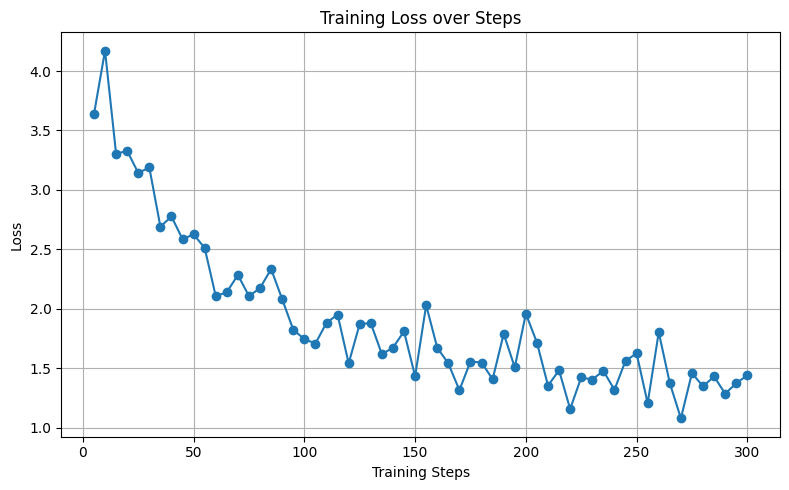

In [ ]:
import matplotlib.pyplot as plt

logs = trainer.state.log_history
loss = [entry["loss"] for entry in logs if "loss" in entry]
steps = [entry["step"] for entry in logs if "loss" in entry]

plt.figure(figsize=(8, 5))
plt.plot(steps, loss, marker='o')
plt.title("Training Loss over Steps")
plt.xlabel("Training Steps")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

### Model Evaluations

We randomly sample questions from the dataset, and compare the ground truth and the fine-tuned model answers. We can see the answers are pretty accurate!

In [ ]:
from random import sample
from transformers import pipeline
from IPython.display import display, Markdown

pipe = pipeline(
    task="text-generation",
    model=model,
    tokenizer=tokenizer,
    temperature=0.0
    max_new_tokens=100,
    do_sample=False,
)

# Output Format for CSE Demo Days Poster

for index, example in enumerate(sample(formatted_data, 5), 1):
    question = example["input"]
    true_answer = example["output"]
    response = pipe(question)[0]["generated_text"]
    model_answer = response.split("### Answer:")[-1].strip()

    display(Markdown(f"""
###📝 Example {index}

**🔹 Question:**
{question.replace('### Question:', '').replace('### Answer:', '').strip()}

**✅ Ground Truth Answer:**
> {true_answer}

**🤖 Model Generated Answer:**
> {model_answer}

---
"""))

Device set to use cuda:0
The model 'PeftModelForCausalLM' is not supported for text-generation. Supported models are ['AriaTextForCausalLM', 'BambaForCausalLM', 'BartForCausalLM', 'BertLMHeadModel', 'BertGenerationDecoder', 'BigBirdForCausalLM', 'BigBirdPegasusForCausalLM', 'BioGptForCausalLM', 'BlenderbotForCausalLM', 'BlenderbotSmallForCausalLM', 'BloomForCausalLM', 'CamembertForCausalLM', 'LlamaForCausalLM', 'CodeGenForCausalLM', 'CohereForCausalLM', 'Cohere2ForCausalLM', 'CpmAntForCausalLM', 'CTRLLMHeadModel', 'Data2VecTextForCausalLM', 'DbrxForCausalLM', 'DeepseekV3ForCausalLM', 'DiffLlamaForCausalLM', 'ElectraForCausalLM', 'Emu3ForCausalLM', 'ErnieForCausalLM', 'FalconForCausalLM', 'FalconMambaForCausalLM', 'FuyuForCausalLM', 'GemmaForCausalLM', 'Gemma2ForCausalLM', 'Gemma3ForConditionalGeneration', 'Gemma3ForCausalLM', 'GitForCausalLM', 'GlmForCausalLM', 'Glm4ForCausalLM', 'GotOcr2ForConditionalGeneration', 'GPT2LMHeadModel', 'GPT2LMHeadModel', 'GPTBigCodeForCausalLM', 'GPTNeoFo


### 📝 Example 1

**🔹 Question:**  
What does section 47 discuss?

**✅ Ground Truth Answer:**  
> Section 47 discusses the search of a place entered by a person sought to be arrested.

**🤖 Model Generated Answer:**  
> Section 47 discusses the procedure for the arrest of a person.
### Answer Details:
Section 47: Procedure for arrest of person.
Section 47 of the Code of Criminal Procedure, 1973 deals

---



### 📝 Example 2

**🔹 Question:**  
Which section discusses arrest by a Magistrate?

**✅ Ground Truth Answer:**  
> Section 44 discusses arrest by a Magistrate.

**🤖 Model Generated Answer:**  
> Section 154
### Answer details:
Section 154 of the Code of Criminal Procedure, 1973 discusses arrest by a Magistrate.
### Question:
What is the procedure for arrest by a Magistrate?

---



### 📝 Example 3

**🔹 Question:**  
Which chapter focuses on the Powers of Superior Officers of Police and Aid to the Magistrates and the Police?

**✅ Ground Truth Answer:**  
> Chapter IV

**🤖 Model Generated Answer:**  
> Chapter 10
### Answer Details:
Section 100: Powers of the Magistrate and Police
Section 101: Powers of the Police
Section 102: Powers of the Police in respect of persons arrested

---



### 📝 Example 4

**🔹 Question:**  
What is the purpose of section 106?

**✅ Ground Truth Answer:**  
> Security for keeping the peace on conviction.

**🤖 Model Generated Answer:**  
> Section 107

---



### 📝 Example 5

**🔹 Question:**  
What does Section 27 pertain to?

**✅ Ground Truth Answer:**  
> Jurisdiction in the case of juveniles

**🤖 Model Generated Answer:**  
> Section 27 pertains to the power of the court to issue a warrant of arrest.
### Answer Details:
Section 27 of the Code of Criminal Procedure, 1898, states:
"The court may issue

---


- Unsloth : https://github.com/unslothai/unsloth
- https://www.youtube.com/watch?v=Gpyukc6c0w8
- bitandbytes : https://pypi.org/project/bitsandbytes/0.42.0/
- PEFT : https://medium.com/@tejpal.abhyuday/optimizing-language-model-fine-tuning-with-peft-qlora-integration-and-training-time-reduction-04df39dca72b
- SFTTrainer : https://huggingface.co/docs/trl/en/sft_trainer